In [24]:
import os, glob
import json
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

"Figure 2" Info from delta and rpdi of every run from homogeneous matchups (must change). For Firm 1.

In [30]:
data = {}
SHOCK_MAP = {
    "shock_none": "No Shock",
    "shock_a":    "Scheme A",
    "shock_b":    "Scheme B",
    "shock_c":    "Scheme C",
}
ALGO_MAP = {
    "q_vs_q":       "Q-Learning",
    "pso_vs_pso":   "PSO",
    "dqn_vs_dqn":   "DDQN",
    "ddpg_vs_ddpg": "DDPG",
}
MARKET_MAP = {
    "LOGIT":     "Logit",
    "HOTELLING": "Hotelling",
    "LINEAR":    "Linear",
}
BASE_DIR = "."

for folder, algo in ALGO_MAP.items():
    data[algo] = {}
    for shock_folder, shock_label in SHOCK_MAP.items():
        data[algo][shock_label] = {}
        pattern = os.path.join(BASE_DIR, folder, "results", "run_*", shock_folder, f"{folder}*.csv")
        files = sorted(glob.glob(pattern))

        for fpath in files:
            df_run = pd.read_csv(fpath)

            for i in range(len(df_run)):
                market_raw = str(df_run.iat[i, 0]).strip().upper()
                market = MARKET_MAP.get(market_raw, market_raw)

                if market not in data[algo][shock_label]:
                    data[algo][shock_label][market] = {"delta": [], "rpdi": []}

                data[algo][shock_label][market]["delta"].append(df_run.iat[i, 5])  # Firm 1 Extra-profits Δ
                data[algo][shock_label][market]["rpdi"].append(df_run.iat[i, 7])   # Firm 1 RPDI

with open("homogeneous_data.json", "w") as file:
    json.dump(data, file, indent=2)


[INFO] Flat data exported to 'homogeneous_data.csv' for manual review.



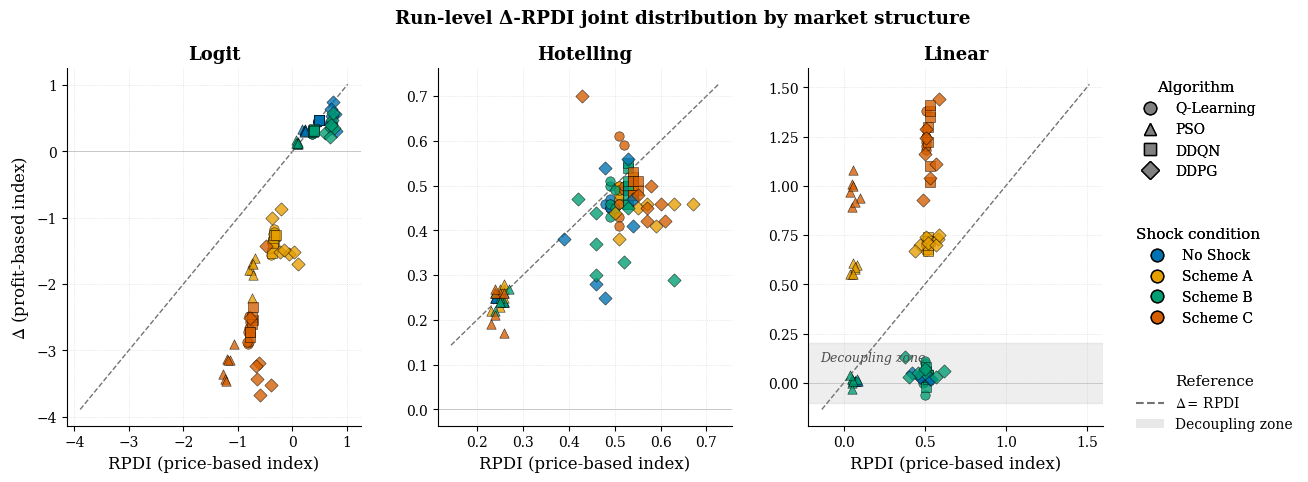

In [35]:
with open("homogeneous_data.json", "r") as f:
    homogeneous_data = json.load(f)

rows = []
# Unpack the nested JSON structure: Algorithm -> Shock -> Market -> Metrics
for algo, shocks in homogeneous_data.items():
    for shock, markets in shocks.items():
        for market, metrics in markets.items():
            deltas = metrics.get("delta", [])
            rpdis = metrics.get("rpdi", [])
            
            # Zip the lists together to construct each individual run entry
            for d, r in zip(deltas, rpdis):
                rows.append({
                    "market": market,
                    "algorithm": algo,
                    "shock": shock,
                    "delta": d,
                    "rpdi": r
                })

# Convert the flattened list of dictionaries into a pandas DataFrame
df = pd.DataFrame(rows)

# CROSS-CHECK VALIDATION
df.to_csv("homogeneous_data.csv", index=False)
print("\n[INFO] Flat data exported to 'homogeneous_data.csv' for manual review.\n")
# ────────────────────────────────────────────────────────────────────────────

# ======================================================================
# 2. STYLE  — Times New Roman everywhere
# ======================================================================
plt.rcParams.update({
    "font.family":"serif",
    "font.serif":["Times New Roman","Times","DejaVu Serif"],
    "mathtext.fontset":"stix",          # Times-like math (for the Δ symbol)
    "font.size":11,
    "axes.titlesize":13,"axes.labelsize":12,
    "xtick.labelsize":10,"ytick.labelsize":10,
    "axes.linewidth":0.8,
})
MARKETS = ["Logit","Hotelling","Linear"]
ALGOS   = ["Q-Learning","PSO","DDQN","DDPG"]
SHOCKS  = ["No Shock","Scheme A","Scheme B","Scheme C"]
SHAPES  = {"Q-Learning":"o","PSO":"^","DDQN":"s","DDPG":"D"}
COLORS  = {"No Shock":"#0072B2","Scheme A":"#E69F00",
           "Scheme B":"#009E73","Scheme C":"#D55E00"}

# ======================================================================
# 3. PLOT
# ======================================================================
fig, axes = plt.subplots(1,3, figsize=(14,4.9))
fig.subplots_adjust(left=0.06, right=0.80, bottom=0.13, top=0.86, wspace=0.26)  # top lowered for title

for ax, market in zip(axes, MARKETS):
    sub = df[df.market==market]
    for algo in ALGOS:
        for shock in SHOCKS:
            d = sub[(sub.algorithm==algo)&(sub.shock==shock)]
            ax.scatter(d.rpdi, d.delta, marker=SHAPES[algo], s=46,
                       facecolor=COLORS[shock], edgecolor="black",
                       linewidth=0.4, alpha=0.78, zorder=3)
    lo = min(sub.rpdi.min(), sub.delta.min()); hi = max(sub.rpdi.max(), sub.delta.max())
    pad = 0.05*(hi-lo)
    ax.plot([lo-pad,hi+pad],[lo-pad,hi+pad], ls="--", color="0.45", lw=1.0, zorder=1)
    if market=="Linear":
        ax.axhspan(-0.10, 0.20, color="0.65", alpha=0.18, zorder=0)
        ax.text(0.04, 0.16, "Decoupling zone", transform=ax.get_yaxis_transform(),
                fontsize=9, style="italic", color="0.3", va="top")
    ax.set_title(market, fontweight="bold")
    ax.set_xlabel("RPDI (price-based index)")
    ax.axhline(0, color="0.8", lw=0.7, zorder=0)
    ax.grid(True, ls=":", lw=0.5, alpha=0.5, zorder=0)
    ax.spines[["top","right"]].set_visible(False)
axes[0].set_ylabel(r"$\Delta$ (profit-based index)")

# ======================================================================
# 4. LEGENDS
# ======================================================================
algo_handles = [Line2D([],[],marker=SHAPES[a],color="none",markerfacecolor="0.5",
                       markeredgecolor="black",markersize=9,label=a) for a in ALGOS]
shock_handles= [Line2D([],[],marker="o",color="none",markerfacecolor=COLORS[s],
                       markeredgecolor="black",markersize=9,label=s) for s in SHOCKS]
ref_handles  = [Line2D([],[],ls="--",color="0.45",label=r"$\Delta=$ RPDI"),
                Patch(facecolor="0.65",alpha=0.25,label="Decoupling zone")]

l1=fig.legend(handles=algo_handles, title="Algorithm", loc="upper left",
              bbox_to_anchor=(0.815,0.86), frameon=False, fontsize=10, title_fontsize=11)
l2=fig.legend(handles=shock_handles, title="Shock condition", loc="upper left",
              bbox_to_anchor=(0.815,0.56), frameon=False, fontsize=10, title_fontsize=11)
l3=fig.legend(handles=ref_handles, title="Reference", loc="upper left",
              bbox_to_anchor=(0.815,0.26), frameon=False, fontsize=10, title_fontsize=11)
fig.add_artist(l1); fig.add_artist(l2)

# ---- TITLE AT TOP (line 1) ----
fig.suptitle("Run-level Δ-RPDI joint distribution by market structure", y=0.98, fontweight='bold')

# ---- SAVE AS IMAGE (line 2) ----
fig.savefig("figure2_run_level_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

figure 3, info from 7, 8, 9

(mean,std) of firm 1 delta
extracted_data = {
 "Logit": {
   "Q-Learning":	[(0.45,0.01),(-1.32,0.13),(0.29,0.02),(-2.73,0.16)],
   "PSO":	[(0.32,0.02),(-1.81,0.20),(0.13,0.02),(-3.22,0.20)],
   "DDQN":	[(0.48,0.00),(-1.36,0.10),(0.32,0.01),(-2.61,0.16)],
   "DDPG":	[(0.52,0.15),(-1.38,0.31),(0.38,0.12),(-3.00,0.79)],
 },
 "Hotelling": {
   "Q-Learning":	[(0.46,0.01),(0.48,0.02),(0.47,0.03),(0.50,0.08)],
   "PSO":	[(0.25,0.01),(0.25,0.02),(0.25,0.02),(0.23,0.04)],
   "DDQN":	[(0.49,0.01),(0.50,0.01),(0.50,0.04),(0.50,0.02)],
   "DDPG":	[(0.41,0.12),(0.44,0.03),(0.38,0.07),(0.49,0.10)],
 },
 "Linear": {
   "Q-Learning":	[(0.04,0.00),(0.70,0.02),(0.04,0.06),(1.25,0.07)],
   "PSO":	[(0.01,0.00),(0.58,0.03),(0.01,0.02),(0.97,0.06)],
   "DDQN":	[(0.04,0.00),(0.71,0.02),(0.04,0.03),(1.25,0.15)],
   "DDPG":	[(0.03,0.01),(0.71,0.03),(0.06,0.03),(1.17,0.17)],
 },
}


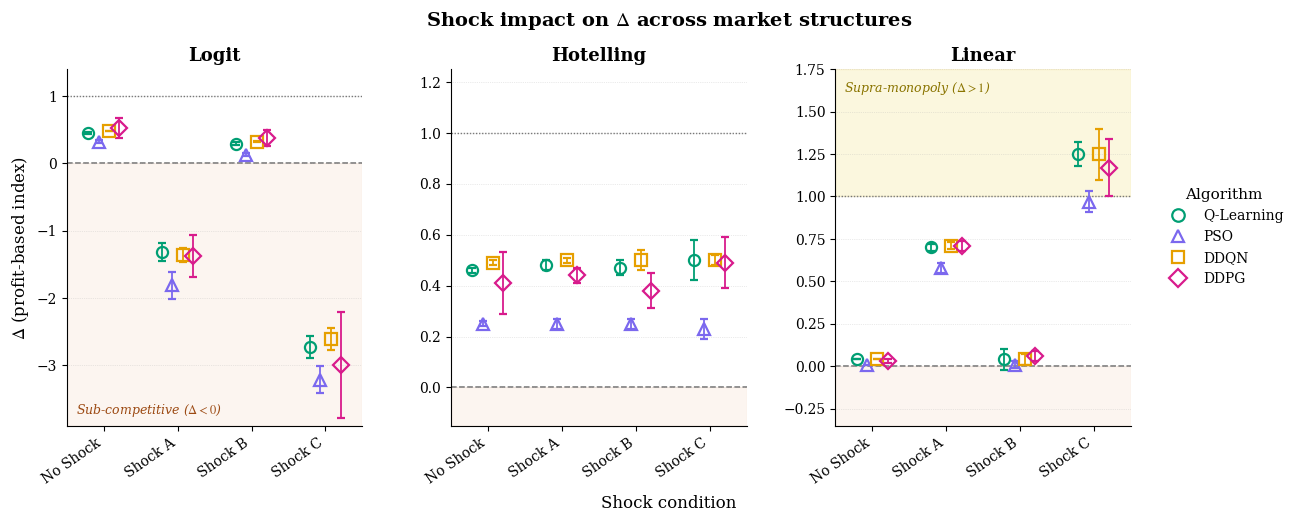

In [40]:
# ======================================================================
# DATA  — Firm-1 Delta mean (SD), n = 7  (Tables 7-9)
# market -> algorithm -> [ (mean,sd) for No Shock, Scheme A, Scheme B, Scheme C ]
# ======================================================================
with open("homogeneous_data.json", "r") as f:
    homogeneous_data = json.load(f)

# 1. Flatten the nested JSON structure into rows
rows = []
for algo, shocks in homogeneous_data.items():
    for shock, markets in shocks.items():
        for market, metrics in markets.items():
            deltas = metrics.get("delta", [])
            for d in deltas:
                rows.append({
                    "market": market,
                    "algorithm": algo,
                    "shock": shock,
                    "delta": d
                })

df = pd.DataFrame(rows)

# 2. Define our structural ordering
MARKETS = ["Logit", "Hotelling", "Linear"]
ALGOS = ["Q-Learning", "PSO", "DDQN", "DDPG"]
SHOCKS = ["No Shock", "Scheme A", "Scheme B", "Scheme C"]

# 3. Aggregate and build the nested dictionary format
extracted_data = {}

for market in MARKETS:
    extracted_data[market] = {}
    for algo in ALGOS:
        stats_list = []
        for shock in SHOCKS:
            # Filter the delta array for this specific cell combination
            cell_deltas = df[(df['market'] == market) & 
                             (df['algorithm'] == algo) & 
                             (df['shock'] == shock)]['delta']
            
            if not cell_deltas.empty:
                # Calculate mean and sample standard deviation (ddof=1)
                mean_val = round(cell_deltas.mean(), 2)
                sd_val = round(cell_deltas.std(ddof=1), 2)
                stats_list.append((mean_val, sd_val))
            else:
                stats_list.append((0.0, 0.0)) # Fallback if combination is missing
                
        extracted_data[market][algo] = stats_list

# 4. Print cleanly formatted python code output
print("(mean,std) of firm 1 delta")
print("extracted_data = {")
for market, algos in extracted_data.items():
    print(f' "{market}": {{')
    for algo, tuples in algos.items():
        # Clean tuple string formatting
        tuple_str = ",".join([f"({m:.2f},{s:.2f})" for m, s in tuples])
        print(f'   "{algo}":\t[{tuple_str}],')
    print(" },")
print("}")

# ======================================================================
# STYLE  — Times New Roman, Okabe-Ito colours (consistent with Figure 2)
# ======================================================================
plt.rcParams.update({
    "font.family":"serif",
    "font.serif":["Times New Roman","Times","DejaVu Serif"],
    "mathtext.fontset":"stix",
    "font.size":11,"axes.titlesize":13,"axes.labelsize":12,
    "xtick.labelsize":10,"ytick.labelsize":10,"axes.linewidth":0.8,
})
MARKETS = ["Logit","Hotelling","Linear"]
ALGOS   = ["Q-Learning","PSO","DDQN","DDPG"]
SHOCKS  = ["No Shock","Shock A","Shock B","Shock C"]
SHAPES  = {"Q-Learning":"o","PSO":"^","DDQN":"s","DDPG":"D"}
COLORS  = {"Q-Learning":"#009E73","PSO":"#7B68EE","DDQN":"#E69F00","DDPG":"#D81B8C"}
OFFSETS = {"Q-Learning":-0.21,"PSO":-0.07,"DDQN":0.07,"DDPG":0.21}   # horizontal jitter

# ======================================================================
# PLOT
# ======================================================================
fig, axes = plt.subplots(1,3, figsize=(14,5.4))
fig.subplots_adjust(left=0.07, right=0.83, bottom=0.20, top=0.86, wspace=0.30)
x = np.arange(len(SHOCKS))

YLIM = {"Logit":(-3.9,1.4), "Hotelling":(-0.15,1.25), "Linear":(-0.35,1.75)}
for ax, market in zip(axes, MARKETS):
    ylo, yhi = YLIM[market]
    ax.set_ylim(ylo, yhi)
    # shaded reference zones (bounded to the visible range so they never drive the limits)
    ax.axhspan(ylo, 0, color="#D55E00", alpha=0.06, zorder=0)            # sub-competitive
    if market=="Linear":
        ax.axhspan(1, yhi, color="#E6C200", alpha=0.13, zorder=0)        # supra-monopoly
    # reference lines
    ax.axhline(0, ls="--", color="0.45", lw=1.1, zorder=1)
    ax.axhline(1, ls=(0,(1,1.2)), color="0.45", lw=1.0, zorder=1)
    # error-bar markers
    for algo in ALGOS:
        m  = np.array([v[0] for v in extracted_data[market][algo]])
        sd = np.array([v[1] for v in extracted_data[market][algo]])
        ax.errorbar(x+OFFSETS[algo], m, yerr=sd, fmt=SHAPES[algo], ms=8,
                    mfc="none", mec=COLORS[algo], mew=1.6,
                    ecolor=COLORS[algo], elinewidth=1.3, capsize=3, capthick=1.3,
                    zorder=3)
    ax.set_title(market, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(SHOCKS, rotation=35, ha="right")
    ax.set_xlim(-0.5, len(SHOCKS)-0.5)
    ax.grid(True, axis="y", ls=":", lw=0.5, alpha=0.5, zorder=0)
    ax.spines[["top","right"]].set_visible(False)
axes[0].set_ylabel(r"$\Delta$ (profit-based index)")

# zone labels (in-panel, italic)
axes[0].text(0.03, 0.02, r"Sub-competitive ($\Delta<0$)", transform=axes[0].transAxes,
             fontsize=9, style="italic", color="#9c4a13", va="bottom")
axes[2].text(0.03, 0.97, r"Supra-monopoly ($\Delta>1$)", transform=axes[2].transAxes,
             fontsize=9, style="italic", color="#8a7400", va="top")

# ======================================================================
# LEGEND (Algorithm) — open markers, right side
# ======================================================================
algo_handles = [Line2D([],[],marker=SHAPES[a],color=COLORS[a],ls="none",
                       mfc="none",mec=COLORS[a],mew=1.6,markersize=9,label=a)
                for a in ALGOS]
fig.legend(handles=algo_handles, title="Algorithm", loc="center left",
           bbox_to_anchor=(0.845,0.55), frameon=False, fontsize=10, title_fontsize=11)

# common x-axis label + title
fig.supxlabel("Shock condition", y=0.04, fontsize=12)
fig.suptitle("Shock impact on $\\Delta$ across market structures",
             y=0.97, fontsize=14, fontweight="bold")

fig.savefig("figure3_shock_impact_delta.png", dpi=300, bbox_inches="tight")
fig.savefig("figure3_shock_impact_delta.pdf", bbox_inches="tight")
plt.show()

Figure 4, info from table 11

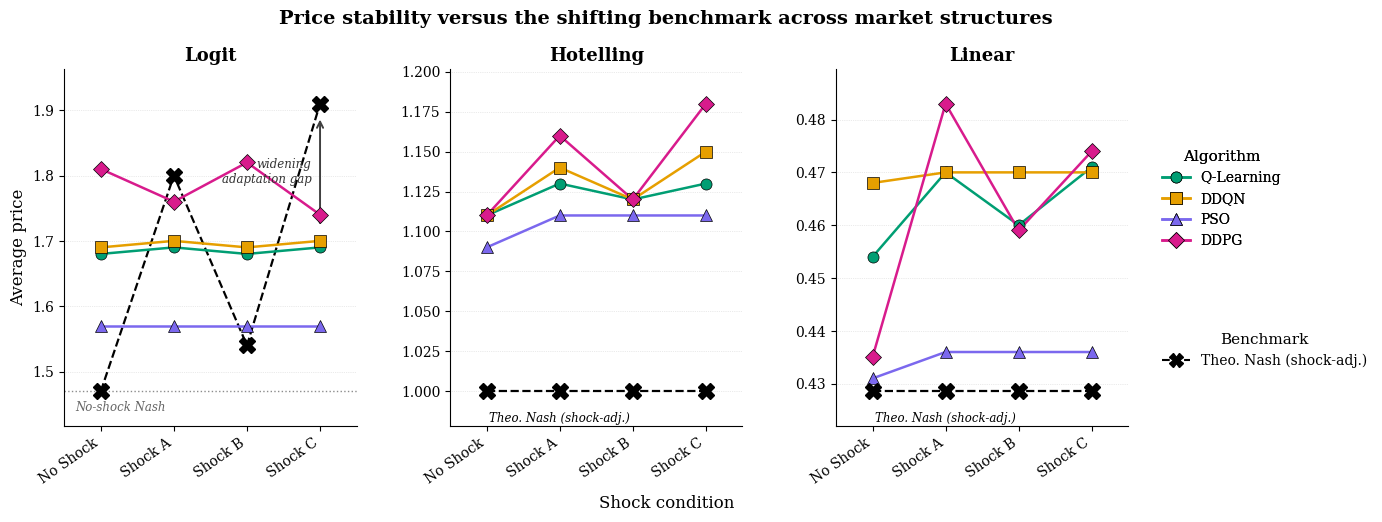

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ======================================================================
# DATA  — Firm-1 average price, mean (SD), n = 7.
# Only the Logit panel has shock-adjusted Nash + full SD (Table 11).
# Hotelling / Linear: prices roughly stable, benchmark FLAT (from the
# original figure). REPLACE Hotelling & Linear means with your real
# Firm-1 average-price tables when finalising.
# market -> algorithm -> [No Shock, Scheme A, Scheme B, Scheme C]
# ======================================================================
price = {
 "Logit": {
   "Q-Learning":[1.68,1.69,1.68,1.69],
   "DDQN":      [1.69,1.70,1.69,1.70],
   "PSO":       [1.57,1.57,1.57,1.57],
   "DDPG":      [1.81,1.76,1.82,1.74],
 },
 "Hotelling": {  # placeholder values matching the original figure shape
   "Q-Learning":[1.11,1.13,1.12,1.13],
   "DDQN":      [1.11,1.14,1.12,1.15],
   "PSO":       [1.09,1.11,1.11,1.11],
   "DDPG":      [1.11,1.16,1.12,1.18],
 },
 "Linear": {     # placeholder values matching the original figure shape
   "Q-Learning":[0.454,0.470,0.460,0.471],
   "DDQN":      [0.468,0.470,0.470,0.470],
   "PSO":       [0.431,0.436,0.436,0.436],
   "DDPG":      [0.435,0.483,0.459,0.474],
 },
}
# shock-adjusted theoretical Nash (black X, dashed)
nash = {
 "Logit":     [1.47,1.80,1.54,1.91],   # Table 11
 "Hotelling": [1.00,1.00,1.00,1.00],   # flat (shocks do not move the benchmark)
 "Linear":    [0.4286,0.4286,0.4286,0.4286],
}
NOSHOCK_LOGIT = 1.47   # un-adjusted Nash reference (Logit only)

# ======================================================================
# STYLE  — Times New Roman, palette consistent with Figs 2-3
# ======================================================================
plt.rcParams.update({
    "font.family":"serif",
    "font.serif":["Times New Roman","Times","DejaVu Serif"],
    "mathtext.fontset":"stix",
    "font.size":11,"axes.titlesize":13,"axes.labelsize":12,
    "xtick.labelsize":10,"ytick.labelsize":10,"axes.linewidth":0.8,
})
MARKETS = ["Logit","Hotelling","Linear"]
ALGOS   = ["Q-Learning","DDQN","PSO","DDPG"]
SHOCKS  = ["No Shock","Shock A","Shock B","Shock C"]
SHAPES  = {"Q-Learning":"o","DDQN":"s","PSO":"^","DDPG":"D"}
COLORS  = {"Q-Learning":"#009E73","DDQN":"#E69F00","PSO":"#7B68EE","DDPG":"#D81B8C"}

# ======================================================================
# PLOT
# ======================================================================
fig, axes = plt.subplots(1,3, figsize=(14,5.4))
fig.subplots_adjust(left=0.07, right=0.83, bottom=0.20, top=0.86, wspace=0.32)
x = np.arange(len(SHOCKS))

for ax, market in zip(axes, MARKETS):
    # algorithm lines + markers
    for algo in ALGOS:
        y = np.array(price[market][algo])
        ax.plot(x, y, color=COLORS[algo], lw=1.8, zorder=3)
        ax.plot(x, y, ls="none", marker=SHAPES[algo], ms=8,
                mfc=COLORS[algo], mec="black", mew=0.5, zorder=4)
    # shock-adjusted Nash: black X + dashed line
    yb = np.array(nash[market])
    ax.plot(x, yb, ls="--", color="black", lw=1.6, zorder=2)
    ax.plot(x, yb, ls="none", marker="X", ms=12, mfc="black", mec="black", zorder=5)
    if market != "Logit":
        ax.annotate("Theo. Nash (shock-adj.)", xy=(x[1], yb[1]),
                    xytext=(0,-15), textcoords="offset points",
                    ha="center", va="top", fontsize=8.5, style="italic")
    # Logit-only extras: no-shock reference + adaptation-gap arrow
    if market=="Logit":
        ax.axhline(NOSHOCK_LOGIT, ls=":", color="0.55", lw=1.0, zorder=1)
        ax.text(x[0]-0.35, NOSHOCK_LOGIT-0.015, "No-shock Nash",
                fontsize=8.5, color="0.4", va="top", style="italic")
        ax.annotate("", xy=(x[3], yb[3]-0.02), xytext=(x[3], price["Logit"]["DDQN"][3]+0.02),
                    arrowprops=dict(arrowstyle="<->", color="0.25", lw=1.4))
        ax.text(x[3]-0.12, (yb[3]+price["Logit"]["DDQN"][3])/2,
                "widening\nadaptation gap", fontsize=8.5, ha="right", va="center",
                style="italic", color="0.2")
    ax.set_title(market, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(SHOCKS, rotation=35, ha="right")
    ax.set_xlim(-0.5, len(SHOCKS)-0.5)
    ax.grid(True, axis="y", ls=":", lw=0.5, alpha=0.5, zorder=0)
    ax.spines[["top","right"]].set_visible(False)
    ax.margins(y=0.12)
axes[0].set_ylabel("Average price")

# ======================================================================
# LEGEND
# ======================================================================
algo_handles = [Line2D([],[],color=COLORS[a],marker=SHAPES[a],ms=8,lw=1.8,
                       mfc=COLORS[a],mec="black",mew=0.5,label=a) for a in ALGOS]
nash_handle  = [Line2D([],[],color="black",ls="--",marker="X",ms=10,
                       label="Theo. Nash (shock-adj.)")]
l1=fig.legend(handles=algo_handles, title="Algorithm", loc="center left",
              bbox_to_anchor=(0.845,0.62), frameon=False, fontsize=10, title_fontsize=11)
l2=fig.legend(handles=nash_handle, title="Benchmark", loc="center left",
              bbox_to_anchor=(0.845,0.34), frameon=False, fontsize=10, title_fontsize=11)
fig.add_artist(l1)

fig.supxlabel("Shock condition", y=0.04, fontsize=12)
fig.suptitle("Price stability versus the shifting benchmark across market structures",
             y=0.97, fontsize=14, fontweight="bold")

fig.savefig("figure4_price_stability.png", dpi=300, bbox_inches="tight")
fig.savefig("figure4_price_stability.pdf", bbox_inches="tight")
plt.show()

figure 5, info from table 12

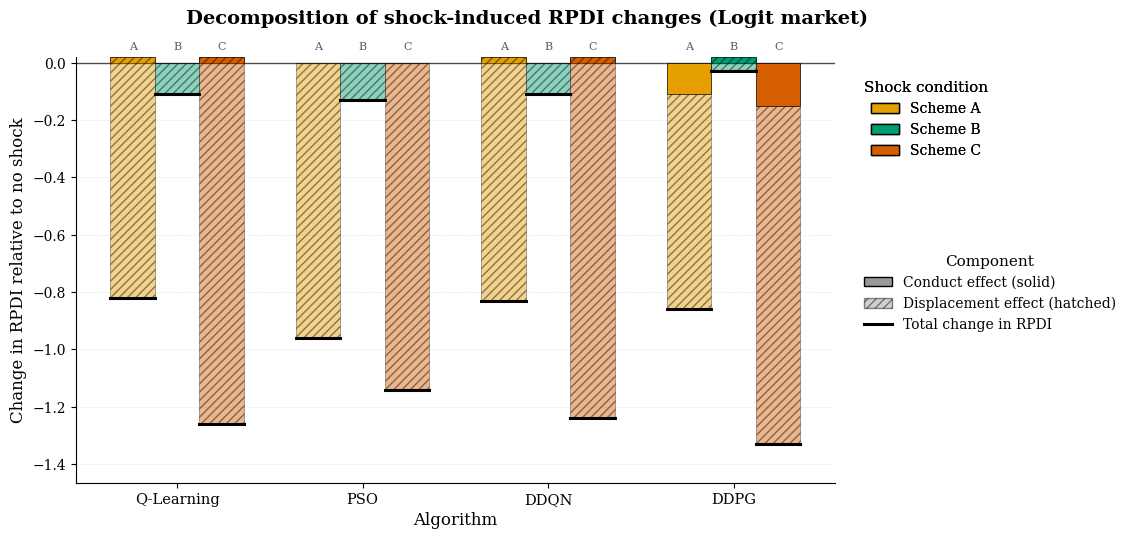

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ======================================================================
# DATA  — Table 12 (Logit, Firm 1). For each algorithm x scheme:
#   conduct effect, displacement effect  (total = conduct + displacement)
# ======================================================================
ALGOS   = ["Q-Learning","PSO","DDQN","DDPG"]
SCHEMES = ["A","B","C"]
conduct = {
 "Q-Learning":{"A":+0.02,"B":0.00,"C":+0.02},
 "PSO":       {"A": 0.00,"B":0.00,"C": 0.00},
 "DDQN":      {"A":+0.02,"B":0.00,"C":+0.02},
 "DDPG":      {"A":-0.11,"B":+0.02,"C":-0.15},
}
displace = {
 "Q-Learning":{"A":-0.84,"B":-0.11,"C":-1.28},
 "PSO":       {"A":-0.96,"B":-0.13,"C":-1.14},
 "DDQN":      {"A":-0.85,"B":-0.11,"C":-1.26},
 "DDPG":      {"A":-0.75,"B":-0.05,"C":-1.18},
}

# ======================================================================
# STYLE  — Times New Roman; one hue per scheme (consistent shock palette)
# ======================================================================
plt.rcParams.update({
    "font.family":"serif",
    "font.serif":["Times New Roman","Times","DejaVu Serif"],
    "mathtext.fontset":"stix",
    "font.size":11,"axes.titlesize":13,"axes.labelsize":12,
    "xtick.labelsize":10.5,"ytick.labelsize":10,"axes.linewidth":0.8,
})
SCHEME_COLOR = {"A":"#E69F00","B":"#009E73","C":"#D55E00"}   # Okabe-Ito A/B/C
W = 0.24                                                     # bar width

# ======================================================================
# PLOT
# ======================================================================
fig, ax = plt.subplots(figsize=(11,5.6))
fig.subplots_adjust(left=0.09, right=0.78, bottom=0.12, top=0.88)

xbase = np.arange(len(ALGOS))
for j, s in enumerate(SCHEMES):
    xpos = xbase + (j-1)*W
    cvals = np.array([conduct[a][s] for a in ALGOS])
    dvals = np.array([displace[a][s] for a in ALGOS])
    tot   = cvals + dvals
    # conduct segment (solid)
    ax.bar(xpos, cvals, width=W, color=SCHEME_COLOR[s], edgecolor="black",
           linewidth=0.5, zorder=3)
    # displacement segment (hatched), stacked from conduct
    ax.bar(xpos, dvals, width=W, bottom=cvals, color=SCHEME_COLOR[s],
           edgecolor="black", linewidth=0.5, alpha=0.45, hatch="////", zorder=3)
    # black tick = total
    for xp, t in zip(xpos, tot):
        ax.plot([xp-W/2, xp+W/2], [t, t], color="black", lw=2.2, zorder=5)

ax.axhline(0, color="0.3", lw=1.0, zorder=2)
ax.set_xticks(xbase); ax.set_xticklabels(ALGOS)
ax.set_ylabel("Change in RPDI relative to no shock")
ax.set_xlabel("Algorithm")
ax.grid(True, axis="y", ls=":", lw=0.5, alpha=0.5, zorder=0)
ax.spines[["top","right"]].set_visible(False)
ax.margins(y=0.10)

# scheme labels above each cluster
for i, a in enumerate(ALGOS):
    for j, s in enumerate(SCHEMES):
        ax.text(xbase[i]+(j-1)*W, 0.04, s, ha="center", va="bottom",
                fontsize=8, color="0.35")

# ======================================================================
# LEGEND  — colour = scheme, fill style = component, tick = total
# ======================================================================
scheme_handles = [Patch(facecolor=SCHEME_COLOR[s], edgecolor="black", label=f"Scheme {s}")
                  for s in SCHEMES]
style_handles  = [Patch(facecolor="0.6", edgecolor="black", label="Conduct effect (solid)"),
                  Patch(facecolor="0.6", edgecolor="black", alpha=0.45, hatch="////",
                        label="Displacement effect (hatched)"),
                  Line2D([],[],color="black",lw=2.2,label="Total change in RPDI")]

l1=fig.legend(handles=scheme_handles, title="Shock condition", loc="upper left",
              bbox_to_anchor=(0.795,0.86), frameon=False, fontsize=10, title_fontsize=11)
l2=fig.legend(handles=style_handles, title="Component", loc="upper left",
              bbox_to_anchor=(0.795,0.55), frameon=False, fontsize=10, title_fontsize=11)
fig.add_artist(l1)

fig.suptitle("Decomposition of shock-induced RPDI changes (Logit market)",
             y=0.965, fontsize=14, fontweight="bold")

fig.savefig("figure5_rpdi_decomposition_logit.png", dpi=300, bbox_inches="tight")
fig.savefig("figure5_rpdi_decomposition_logit.pdf", bbox_inches="tight")
plt.show()